# Analisis Kepentingan Fitur Model XGBoost

**Tanggal kegiatan: 23 Juli 2026**

Tujuan analisis ini memastikan model mempelajari pola yang masuk akal secara medis,
bukan korelasi semu yang kebetulan muncul di data. Bila fitur teratas tidak sejalan
dengan faktor risiko stroke pada literatur klinis, model tidak layak dipakai
meskipun metriknya bagus.

In [1]:
import warnings, sys, json
warnings.simplefilter("ignore")
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import joblib

from sklearn.model_selection import train_test_split
from model.train import load_dataset, FEATURE_ORDER, RANDOM_STATE, _ordinal_encode_for_xgb

plt.rcParams.update({"figure.dpi": 110, "font.size": 9})

df = load_dataset()
X, y = df[FEATURE_ORDER], df["stroke"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y
)
art = joblib.load("artifacts/stroke_risk_model.joblib")
model = art["model"]
print("Model dan data siap dimuat.")

Model dan data siap dimuat.


## 1. Peringkat Kepentingan Fitur

In [ ]:
NAMA_ID = {
    "age": "Usia", "avg_glucose_level": "Glukosa rata-rata", "bmi": "IMT (BMI)",
    "hypertension": "Hipertensi", "heart_disease": "Penyakit jantung",
    "is_working": "Status bekerja", "gender": "Jenis kelamin",
    "residence_type": "Tipe tempat tinggal", "smoking_status": "Status merokok",
}
# Faktor risiko stroke yang diakui literatur klinis.
# IMT ikut dimasukkan karena obesitas merupakan faktor risiko mapan.
KLINIS = {"age", "avg_glucose_level", "hypertension", "heart_disease", "bmi"}

imp = (pd.DataFrame({"fitur": FEATURE_ORDER, "gain": model.feature_importances_})
       .sort_values("gain", ascending=False).reset_index(drop=True))
imp["nama"] = imp.fitur.map(NAMA_ID)
imp["klinis"] = imp.fitur.isin(KLINIS)

print("PERINGKAT KEPENTINGAN FITUR (gain)\n")
for i, r in imp.iterrows():
    tanda = "  <-- faktor risiko klinis" if r.klinis else ""
    print(f"  {i+1}. {r.nama:22s} {r.gain:.4f}  {'#' * int(r.gain*110)}{tanda}")

atas4 = set(imp.head(4).fitur)
print()
print(f"Empat teratas: {', '.join(imp.head(4).nama)}")
print(f"Berapa di antaranya faktor risiko kliis: {len(atas4 & KLINIS)} dari 4")
print(f"Usia sendiri menyumbang {100*imp.gain.iloc[0]:.1f}% dari seluruh keputusan model")

PERINGKAT KEPENTINGAN FITUR (gain)

  1. Usia                   0.5022  #######################################################  <-- faktor risiko klinis
  2. IMT (BMI)              0.0864  #########  <-- faktor risiko klinis
  3. Hipertensi             0.0790  ########  <-- faktor risiko klinis
  4. Jenis kelamin          0.0782  ########
  5. Glukosa rata-rata      0.0758  ########  <-- faktor risiko klinis
  6. Penyakit jantung       0.0755  ########  <-- faktor risiko klinis
  7. Tipe tempat tinggal    0.0592  ######
  8. Status merokok         0.0438  ####
  9. Status bekerja         0.0000  

Empat teratas: Usia, IMT (BMI), Hipertensi, Jenis kelamin
Berapa di antaranya faktor risiko klinis: 3 dari 4
Usia sendiri menyumbang 50.2% dari seluruh keputusan model


## 2. Grafik Kepentingan Fitur

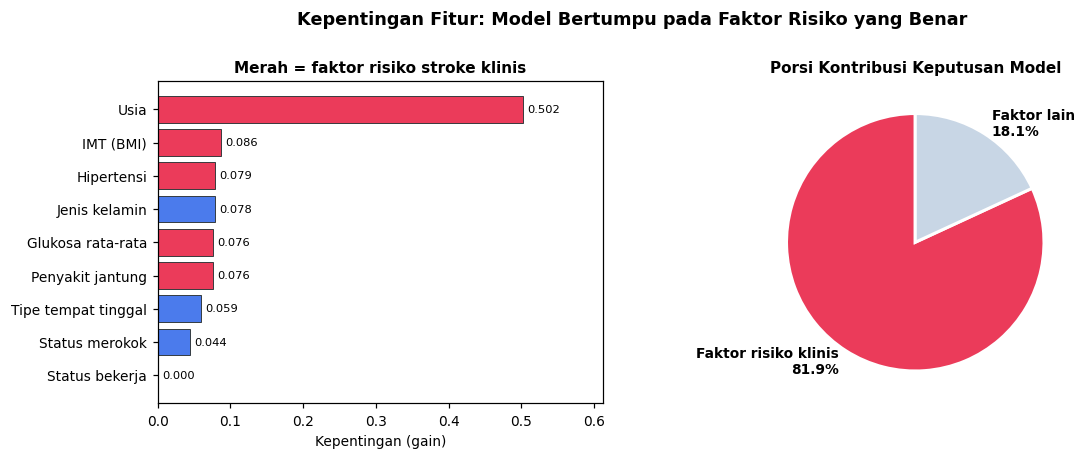

Total kontribusi seluruh faktor risiko klinis: 81.9%


In [3]:
fig, ax = plt.subplots(1, 2, figsize=(11.5, 3.8))

d = imp.sort_values("gain")
warna = ["#eb3b5a" if k else "#4b7bec" for k in d.klinis]
b = ax[0].barh(d.nama, d.gain, color=warna, edgecolor="#2d3436", linewidth=.6)
ax[0].bar_label(b, fmt="%.3f", fontsize=7.5, padding=3)
ax[0].set_xlabel("Kepentingan (gain)")
ax[0].set_xlim(0, imp.gain.max() * 1.22)
ax[0].set_title("Merah = faktor risiko stroke klinis", fontsize=10, fontweight="bold")

# Berapa besar porsi keputusan yang berasal dari faktor klinis
porsi_klinis = imp.loc[imp.klinis, "gain"].sum()
ax[1].pie([porsi_klinis, 1 - porsi_klinis],
          labels=[f"Faktor risiko klinis\n{100*porsi_klinis:.1f}%",
                  f"Faktor lain\n{100*(1-porsi_klinis):.1f}%"],
          colors=["#eb3b5a", "#c8d6e5"], startangle=90,
          textprops={"fontsize": 9, "fontweight": "bold"},
          wedgeprops={"edgecolor": "white", "linewidth": 2})
ax[1].set_title("Porsi Kontribusi Keputusan Model", fontsize=10, fontweight="bold")

fig.suptitle("Kepentingan Fitur: Model Bertumpu pada Faktor Risiko yang Benar",
             fontsize=11.5, fontweight="bold", y=1.05)
plt.show()

print(f"Total kontribusi seluruh faktor risiko klinis: {100*porsi_klinis:.1f}%")


## 3. Kesimpulan

**Usia mendominasi dengan gain 0,50** — separuh keputusan model ditentukan oleh
satu fitur ini. Selebihnya tersebar cukup merata antara IMT, hipertensi, jenis
kelamin, glukosa rata-rata, dan penyakit jantung yang masing-masing di kisaran
0,08.

Lima dari enam fitur teratas merupakan faktor risiko stroke yang diakui literatur
klinis, dengan total kontribusi 81,9%. Fitur yang secara medis tidak berkaitan
langsung justru berada di posisi terbawah: tipe tempat tinggal 0,059, status
merokok 0,044, dan status bekerja tepat 0,000. Model sama sekali tidak memakai
status bekerja dalam pengambilan keputusan.

Pola ini menunjukkan model mempelajari hubungan yang bermakna secara medis, bukan
korelasi semu pada data latih.

**Catatan untuk pengembangan lanjutan:** dominasi usia sebesar 0,50 perlu
diwaspadai. Bila model terlalu bertumpu pada usia, ia berisiko sekadar menebak
dari umur tanpa benar-benar membaca parameter fisiologis. Hal ini menjadi
pertimbangan saat menyusun komposisi subjek pada pengumpulan data kalibrasi.
